# 데이터 전처리
- `데이터 전처리`란 데이터를 모델이나 분석에 쓰기 좋은 상태로 바꾸는 판단 과정
- 데이터를 확인하고, 중복값 제거, 결측치 처리, 변수 변환, 이상값 처리, 정규화 등의 작업을 진행함

In [2]:
from pickletools import dis

import pandas as pd
from altair.vegalite.v6 import display

In [3]:
# csv 읽어오기
contact_df = pd.read_csv('./data/contacts.csv')
contact_df

,Name,Phone,Email
0,김민수,010-1234-5678,minsu.kim@gmail.com
1,이지은,010-2345-6789,jieun.lee@naver.com
2,박철수,010-3456-7890,chulsoo.park@hotmail.com
3,홍길동,010-4567-8901,gildong.hong@daum.net
4,김영희,010-5678-9012,younghee.kim@gmail.com
...,...,...,...
72,범수정,010-3456-7892,soojeong.beom@gmail.com
73,이호진,010-4567-8904,hojin.lee@daum.net
74,정지윤,010-5678-9015,jungzee@naver.com
75,김지현,010-6789-0126,jh.kim@gmail.com


In [4]:
contact_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Name    77 non-null     str  
 1   Phone   71 non-null     str  
 2   Email   76 non-null     str  
dtypes: str(3)
memory usage: 5.1 KB


In [5]:
# 수치형 데이터 컬럼이 없으면 사분위수(min, 25%, 50%, 75%, max) 출력 X
# - freq(최빈값) 확인 == 중복 데이터 여부 확인
contact_df.describe()

,Name,Phone,Email
count,77,71,76
unique,75,63,75
top,박철수,010-2345-6789,dahyun.jung@naver.com
freq,2,2,2


## 01. 중복값 처리


In [6]:
# 중복값 확인
# print(contact_df[contact_df['Name'] == '박철수']) # '박철수' 행 모두 조회
print(contact_df.loc[contact_df['Name'] == '박철수']) # '박철수' 행 모두 조회

print(contact_df.loc[contact_df['Phone'] == '010-2345-6789'])

print(contact_df.loc[contact_df['Email'] == 'dahyun.jung@naver.com'])

   Name          Phone                     Email
2   박철수  010-3456-7890  chulsoo.park@hotmail.com
31  박철수  010-1234-5681    chulsoo.park@gmail.com
   Name          Phone                     Email
1   이지은  010-2345-6789       jieun.lee@naver.com
71  엄정희  010-2345-6789  jeonghee.eom@hotmail.com
   Name          Phone                  Email
32  정다현  010-2345-6782  dahyun.jung@naver.com
67  정다현  010-2345-6782  dahyun.jung@naver.com


In [7]:
# 중복 여부 확인

# 전체 컬럼 값 중복 확인
# contact_df.duplicated():
# 데이터프레임 내에서 모든 컬럼값이 일치하는 행 -> True, 아니면 False
display(contact_df[contact_df.duplicated()])
print("전체 중복 행 수:",contact_df.duplicated().sum())

,Name,Phone,Email
67,정다현,010-2345-6782,dahyun.jung@naver.com


전체 중복 행 수: 1


In [8]:
# 이름 컬럼 값 중복 확인
print(contact_df.loc[contact_df['Name'].duplicated()])
print("이름 중복 수:", contact_df['Name'].duplicated().sum())

   Name          Phone                   Email
31  박철수  010-1234-5681  chulsoo.park@gmail.com
67  정다현  010-2345-6782   dahyun.jung@naver.com
이름 중복 수: 2


In [9]:
# 이메일 중복 행, count 출력
print(contact_df.loc[contact_df['Email'].duplicated()])
print("이메일 중복 수:", contact_df['Email'].duplicated().sum())

   Name          Phone                  Email
67  정다현  010-2345-6782  dahyun.jung@naver.com
이메일 중복 수: 1


In [10]:
# 이름 + 전화번호 두 컬럼 중복
# keep=False -> 중복되는 행 모두 출력
display(
    contact_df
    .loc[contact_df.duplicated(['Name', 'Phone'], keep=False)])

# 중복되는 행의 RangeIndex 반환
print(contact_df.loc[contact_df.duplicated()].index)

,Name,Phone,Email
32,정다현,010-2345-6782,dahyun.jung@naver.com
67,정다현,010-2345-6782,dahyun.jung@naver.com


RangeIndex(start=67, stop=68, step=1)


In [11]:
# 중복 제거 기준
# 1. 이름만 같은 경우는 '동명이인'일 가능성이 있으므로 제거 X
# 2. 이름과 전화번호가 함께 같으면 동일인일 가능성이 높다 -> 제거 O

# keep='first' -> 중복 행 중 첫 번째는 제거하지 말고 남겨라
contact_df = contact_df.drop_duplicates(['Name', 'Phone'], keep='first')
print("중복 제거 후 shape: ", contact_df.shape) # (77,3) -> (76,3)

중복 제거 후 shape:  (76, 3)


## 02. 결측치 처리
- `info()`: 컬럼별 데이터 개수와 자료형을 확인해 결측치 존재 여부를 빠르게 파악함
- `isna()`: 각 데이터가 결측치인지 `True/False`로 확인함
- `isnull()`: `isna()`와 같은 기능으로, 각 데이터가 결측치인지 확인함
- `fillna()`: 결측치를 특정 값, 평균값, 최빈값 등으로 채움

In [12]:
# 모든 컬럼의 결측치 확인
display(contact_df.isna())
print(contact_df.isna().sum())

,Name,Phone,Email
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
72,False,False,False
73,False,False,False
74,False,False,False
75,False,False,False


Name     0
Phone    6
Email    1
dtype: int64


In [13]:
# 특정 컬럼만 결측치 확인
contact_df['Phone'].isnull().sum()

np.int64(6)

In [14]:
# 결측치 처리
# 1. 기본값으로 처리(숫자:0, 문자:'' 등)
# 2. (수치형 컬럼인 경우) 평균 값으로 처리
# 3. 결측치가 포함된 행 제거
contact_df[contact_df['Phone'].isna()]

# Phone 컬럼 값이 결측치인 경우 기본값('010-0000-0000')으로 처리
contact_df['Phone'] = contact_df['Phone'].fillna('010-0000-0000')
contact_df

,Name,Phone,Email
0,김민수,010-1234-5678,minsu.kim@gmail.com
1,이지은,010-2345-6789,jieun.lee@naver.com
2,박철수,010-3456-7890,chulsoo.park@hotmail.com
3,홍길동,010-4567-8901,gildong.hong@daum.net
4,김영희,010-5678-9012,younghee.kim@gmail.com
...,...,...,...
72,범수정,010-3456-7892,soojeong.beom@gmail.com
73,이호진,010-4567-8904,hojin.lee@daum.net
74,정지윤,010-5678-9015,jungzee@naver.com
75,김지현,010-6789-0126,jh.kim@gmail.com


In [15]:
# 결측치가 존재하는 행 제거 (dropna())
#contact_df.dropna() # 컬럼 값 중 하나라도 결측치가 존재하면 행 제거
#contact_df.dropna(how='any') # 기본값
contact_df.dropna(how='all') # 모든 컬럼 값이 결측치인 경우 제거

,Name,Phone,Email
0,김민수,010-1234-5678,minsu.kim@gmail.com
1,이지은,010-2345-6789,jieun.lee@naver.com
2,박철수,010-3456-7890,chulsoo.park@hotmail.com
3,홍길동,010-4567-8901,gildong.hong@daum.net
4,김영희,010-5678-9012,younghee.kim@gmail.com
...,...,...,...
72,범수정,010-3456-7892,soojeong.beom@gmail.com
73,이호진,010-4567-8904,hojin.lee@daum.net
74,정지윤,010-5678-9015,jungzee@naver.com
75,김지현,010-6789-0126,jh.kim@gmail.com


### 02-1. 결측치 조회 관련

1. **`any()`**:
   - 하나라도 `True`인 값이 있으면 `True`를 반환.
   - 축(axis)을 지정하면 해당 축 방향으로 `any` 조건을 평가.

   ```python
   df.isnull().any(axis=1)  # 각 행에 대해 결측값이 있는지 확인
   ```

2. **`all()`**:
   - 모든 값이 `True`이면 `True`를 반환.
   - 축(axis)을 지정하면 해당 축 방향으로 `all` 조건을 평가.

   ```python
   df.isnull().all(axis=0)  # 각 열에 대해 모두 결측값인지 확인
   ```

3. **`sum()`**:
   - `True`를 `1`, `False`를 `0`으로 간주해 합계를 계산.
   - 결측값의 개수를 빠르게 확인하는 데 사용.

   ```python
   df.isnull().sum()  # 각 열에 대한 결측값의 개수
   ```

4. **`mean()`**:
   - `True`를 `1`, `False`를 `0`으로 간주해 평균을 계산.
   - 결측값 비율을 확인할 때 유용.

   ```python
   df.isnull().mean()  # 각 열에 대한 결측값 비율
   ```

5. **`idxmax()`**:
   - 가장 먼저 `True`가 나오는 인덱스를 반환.
   - 결측값이 처음으로 나타나는 위치를 찾을 때 사용.

   ```python
   df.isnull().idxmax()  # 각 열에서 결측값이 처음 나타나는 행의 인덱스
   ```

6. **`idxmin()`**:
   - 가장 먼저 `False`가 나오는 인덱스를 반환.

   ```python
   df.isnull().idxmin()  # 결측값이 아닌 값이 처음 나타나는 인덱스
   ```

7. **`astype(int)`**:
   - `True/False`를 `1/0`으로 변환해 DataFrame의 연산에 사용.

   ```python
   df.isnull().astype(int)  # 결측값을 1로 변환
   ```
**축(`axis`) 옵션**
- **`axis=0`** (기본값): 열(column) 단위로 연산.
- **`axis=1`**: 행(row) 단위로 연산.

In [16]:
import numpy as np

data = {
    "A": [1, np.nan, 2, np.nan],
    "B": [3, 4, 5, 6]
}
df = pd.DataFrame(data)
df

,A,B
0,1.0,3
1,NaN,4
2,2.0,5
3,NaN,6


In [17]:
# any(): 결측치가 하나라도 있는 경우 True
df.isna().any()

A     True
B    False
dtype: bool

In [18]:
# all(): 모두 결측치인 경우 True
df.isna().all()

A    False
B    False
dtype: bool

In [19]:
# axis 속성
# 2차원 axis = 0  -> 행 진행 방향 == 열 단위로 선택
# 2차원 axis = 1  -> 열 진행 방향 == 행 단위로 선택
df.isna().any(axis=0)

A     True
B    False
dtype: bool

In [20]:
df.isna().any(axis=1)

0    False
1     True
2    False
3     True
dtype: bool

In [21]:
# idxmin(): 결측치가 아닌 첫 데이터의 인덱스
# idxmax(): 첫 결측치 데이터의 인덱스
print(df.isna().idxmin())
print(df.isna().idxmax())

A    0
B    0
dtype: int64
A    1
B    0
dtype: int64


## 03. 데이터 전처리 보강

전처리는 단순히 코드를 외우는 단원이 아니라, **데이터를 모델이나 분석에 쓰기 좋은 상태로 바꾸는 판단 과정**이다.

1. 데이터 확인: 행/열, 자료형, 결측치, 중복 확인
2. 값 정리: 컬럼명, 자료형, 잘못된 값, 표현 방식 통일
3. 변수 변환: 기존 컬럼을 이용해 분석에 더 유용한 컬럼 생성
4. 결측치/이상값 처리: 삭제할지, 대체할지, 별도 표시할지 판단
5. 스케일 조정: 정규화/표준화로 값의 범위를 맞춤


In [22]:
import pandas as pd
import numpy as np

# np.nan은 NumPy에서 제공하는 결측값 표현이며, Pandas에서는 결측치로 인식됨
# 실제 현업 데이터에서도 구매금액, 소득, 나이, 등급처럼 일부 값이 비어 있는 경우가 자주 있음
customer_df = pd.DataFrame({
    "customer_id": [101, 102, 103, 104, 105, 106, 107],
    "name": ["김민수", "이지은", "박철수", "홍길동", "김영희", "정다현", "최서준"],
    "purchase1": [120000, 350000, 80000, 500000, np.nan, 150000, 70000],
    "purchase2": [90000, 120000, 40000, 620000, 30000, np.nan, 65000],
    "income": [3200, 5400, np.nan, 9100, 2800, 4500, 3000],
    "age": [25, 38, np.nan, 45, 29, 33, np.nan],
    "grade": ["basic", "vip", "basic", "vvip", None, "vip", "basic"],
    "join_date": ["2024-01-15", "2023-11-02", "2024-03-20", "2022-07-08", "2024-04-01", "2023-05-10", "2024-02-18"],
})

display(customer_df)
customer_df.info()

,customer_id,name,purchase1,purchase2,income,age,grade,join_date
0,101,김민수,120000.0,90000.0,3200.0,25.0,basic,2024-01-15
1,102,이지은,350000.0,120000.0,5400.0,38.0,vip,2023-11-02
2,103,박철수,80000.0,40000.0,NaN,NaN,basic,2024-03-20
3,104,홍길동,500000.0,620000.0,9100.0,45.0,vvip,2022-07-08
4,105,김영희,NaN,30000.0,2800.0,29.0,NaN,2024-04-01
5,106,정다현,150000.0,NaN,4500.0,33.0,vip,2023-05-10
6,107,최서준,70000.0,65000.0,3000.0,NaN,basic,2024-02-18


<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  7 non-null      int64  
 1   name         7 non-null      str    
 2   purchase1    6 non-null      float64
 3   purchase2    6 non-null      float64
 4   income       6 non-null      float64
 5   age          5 non-null      float64
 6   grade        6 non-null      str    
 7   join_date    7 non-null      str    
dtypes: float64(4), int64(1), str(3)
memory usage: 739.0 bytes


### 03-1. 변수 변환: 파생변수, 요약변수, 기준점 정의
- 파생변수: 기존 컬럼을 계산해서 새로 만든 컬럼
    - 예를 들어 `purchase1`, `purchase2`만 있으면 각 구매 기록은 볼 수 있지만, 고객별 전체 구매 규모는 바로 보이지 않음.
    - 이때 `total_purchase`라는 파생 변수를 만들면 고객별 구매 규모를 한 번에 비교할 수 있음.

- 요약변수: 여러 컬럼을 하나로 요약해서 새로운 컬럼을 만든 것
- 기준점 정의: 평균, 중앙값, 특정 기준값을 기준으로 데이터를 해석하기 쉽게 바꾸는 작업


In [23]:
customer_work_df = customer_df.copy() # 원본 유지를 위해 df 복사

# 파생 변수: 기존 컬럼을 계산해서 새로 만든 컬럼
# (중요!) 연산되는 값 중 결측치(NaN)가 포함되면 결과는 무조건 결측치(NaN)
customer_work_df['total_purchase'] = (
        customer_work_df['purchase1'] + customer_work_df['purchase2'])

# 평균 구매 금액을 구해서 'avg_purchase' 컬럼으로 추가 (== 파생 변수)
# skipna=True -> 평균 계산 시 결측치를 제외
customer_work_df['avg_purchase'] = (
    customer_work_df[['purchase1', 'purchase2']].mean(axis=1, skipna=True)
)

# 기준점 정의: 특정 기준점을 정해서 이를 이용해 해석하기 쉬운 컬럼을 생성
# - 전체 소득 평균을 기준으로 하여
# 각 고객의 소득이 평균보다 높음/낮음/근처/소득없음 으로 구분

# 소득 평균
income_mean = customer_work_df['income'].mean()

# 소득을 전달 받아서 높음/낮음/근처/소득없음 문자열로 반환하는 함수
def categorize_income(income):
    if pd.isna(income): # 결측치는 비교연산(==) 사용 불가
        return '소득 없음'
    if income >= income_mean + 1000:
        return '평균보다 높음'
    if income <= income_mean - 1000:
        return '평균보다 낮음'
    return '평균 근처'

customer_work_df['income_level'] = (
    customer_work_df['income'].apply(categorize_income))

display(customer_work_df)
print("소득평균: ", income_mean)

,customer_id,name,purchase1,purchase2,income,age,grade,join_date,total_purchase,avg_purchase,income_level
0,101,김민수,120000.0,90000.0,3200.0,25.0,basic,2024-01-15,210000.0,105000.0,평균보다 낮음
1,102,이지은,350000.0,120000.0,5400.0,38.0,vip,2023-11-02,470000.0,235000.0,평균 근처
2,103,박철수,80000.0,40000.0,NaN,NaN,basic,2024-03-20,120000.0,60000.0,소득 없음
3,104,홍길동,500000.0,620000.0,9100.0,45.0,vvip,2022-07-08,1120000.0,560000.0,평균보다 높음
4,105,김영희,NaN,30000.0,2800.0,29.0,NaN,2024-04-01,NaN,30000.0,평균보다 낮음
5,106,정다현,150000.0,NaN,4500.0,33.0,vip,2023-05-10,NaN,150000.0,평균 근처
6,107,최서준,70000.0,65000.0,3000.0,NaN,basic,2024-02-18,135000.0,67500.0,평균보다 낮음


소득평균:  4666.666666666667


### 03-2. 값 변환: `rename`, `map`, `replace`, `astype`, `to_datetime`
전처리에서는 값 자체를 바꾸는 일도 많음

- `rename`: 컬럼명을 더 이해하기 쉽게 변경
- `map`: 값 하나하나를 다른 값으로 매핑
- `replace`: 특정 값을 다른 값으로 치환
- `astype`: 자료형 변환
- `to_datetime`: 문자열 날짜를 날짜형으로 변환


In [24]:
# rename(): 컬럼명을 변경함
# 원본 customer_work_df의 컬럼명은 유지하고, 바뀐 컬럼명을 가진 새 DataFrame을 renamed_df를 반환 받음
renamed_df = customer_work_df.rename(columns={
    "customer_id": "id",
    "total_purchase": "total_amount",
    "avg_purchase": "avg_amount",
}).copy()

# display(customer_work_df)
#display(renamed_df)

# grade_map: 등급 문자열을 숫자 점수로 바꾸기 위한 매핑표
grade_map = {
    "basic": 1,
    "vip": 2,
    "vvip": 3,
}

# map(): 값 변환표를 이용해 Series의 값을 다른 값으로 변환.
# grade가 basic이면 1, vip이면 2, vvip이면 3으로 변환
# 매핑표에 없는 값이나 결측치는 NaN으로 남을 수 있음
renamed_df["grade_score"] = renamed_df["grade"].map(grade_map)
#display(renamed_df)


# replace(): 특정 값을 다른 값으로 치환.
# map()은 변환표에 없는 값이 나오면 “어떻게 바꿀지 모르겠는데?” 하면서 NaN으로 만들 수 있다.
# replace()는 변환표에 없는 값은 “내가 바꾸라고 한 값이 아니네” 하고 그대로 둔다.
renamed_df["grade_label"] = renamed_df["grade"].replace({
    "basic": "일반",
    "vip": "우수",
    "vvip": "최우수",
})
#display(renamed_df)

print(renamed_df.info())
# to_datetime(): 문자열로 저장된 날짜를 날짜/시간 타입으로 변환.
# 날짜 타입으로 바꾸면 월별 집계, 기간 계산, 정렬을 더 안정적으로 할 수 있음
renamed_df["join_date"] = pd.to_datetime(renamed_df["join_date"])


# astype(): 자료형을 변환
# age에는 결측치가 있으므로 바로 int로 바꾸면 오류 발생함
# 그래서 평균값으로 결측치를 채우고, 반올림한 뒤 정수형으로 변환
renamed_df["age_fill"] = renamed_df["age"].fillna(renamed_df["age"].mean()).round().astype(int)

# 변환 전후를 비교하기 위해 원본 등급/나이 컬럼과 새 컬럼을 함께 출력
display(renamed_df[["id", "name", "grade", "grade_score", "grade_label", "join_date", "age", "age_fill"]])

# info()로 join_date가 datetime 타입이 되었는지, age_fill이 int 타입인지 확인
renamed_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            7 non-null      int64  
 1   name          7 non-null      str    
 2   purchase1     6 non-null      float64
 3   purchase2     6 non-null      float64
 4   income        6 non-null      float64
 5   age           5 non-null      float64
 6   grade         6 non-null      str    
 7   join_date     7 non-null      str    
 8   total_amount  5 non-null      float64
 9   avg_amount    7 non-null      float64
 10  income_level  7 non-null      str    
 11  grade_score   6 non-null      float64
 12  grade_label   6 non-null      str    
dtypes: float64(7), int64(1), str(5)
memory usage: 1.1 KB
None


,id,name,grade,grade_score,grade_label,join_date,age,age_fill
0,101,김민수,basic,1.0,일반,2024-01-15,25.0,25
1,102,이지은,vip,2.0,우수,2023-11-02,38.0,38
2,103,박철수,basic,1.0,일반,2024-03-20,NaN,34
3,104,홍길동,vvip,3.0,최우수,2022-07-08,45.0,45
4,105,김영희,NaN,NaN,NaN,2024-04-01,29.0,29
5,106,정다현,vip,2.0,우수,2023-05-10,33.0,33
6,107,최서준,basic,1.0,일반,2024-02-18,NaN,34


<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            7 non-null      int64         
 1   name          7 non-null      str           
 2   purchase1     6 non-null      float64       
 3   purchase2     6 non-null      float64       
 4   income        6 non-null      float64       
 5   age           5 non-null      float64       
 6   grade         6 non-null      str           
 7   join_date     7 non-null      datetime64[us]
 8   total_amount  5 non-null      float64       
 9   avg_amount    7 non-null      float64       
 10  income_level  7 non-null      str           
 11  grade_score   6 non-null      float64       
 12  grade_label   6 non-null      str           
 13  age_fill      7 non-null      int64         
dtypes: datetime64[us](1), float64(7), int64(2), str(4)
memory usage: 1.1 KB


### 03-3. 결측치 처리 보강: `notna`, 평균대치, 단순확률대치
결측치 처리는 무조건 삭제하는 작업이 아님

- 삭제: 행 수가 충분하고, 결측치가 분석에 큰 영향을 주지 않을 때
- 평균/중앙값 대치: 수치형 변수의 대표값으로 채울 때
- 최빈값 대치: 범주형 변수에서 가장 자주 등장한 값으로 채울 때
- 단순확률대치: 실제 관측된 값 중 하나를 무작위로 뽑아 채울 때

`isna()`가 결측치인지 확인한다면, `notna()`는 **결측치가 아닌 정상 값인지** 확인한다.


In [26]:
# custom_work_df 복사
missing_df = customer_work_df.copy()

print("컬럼별 결측치")
print(missing_df.isna().sum())

# notna(): 결측치가 아니면 True
print("컬럼별 결측치가 아닌 값")
print(missing_df.notna().sum())

컬럼별 결측치
customer_id       0
name              0
purchase1         1
purchase2         1
income            1
age               2
grade             1
join_date         0
total_purchase    2
avg_purchase      0
income_level      0
dtype: int64
컬럼별 결측치가 아닌 값
customer_id       7
name              7
purchase1         6
purchase2         6
income            6
age               5
grade             6
join_date         7
total_purchase    5
avg_purchase      7
income_level      7
dtype: int64


In [28]:
# 평균대치
# - 장점: 간단하고 빠름
# - 단점: 데이터의 퍼짐 정도가 줄어들고, 실제 개별 특성을 반영하지 못할 수 있음.
# age 컬럼에 결측치가 존재하면 age 평균으로 대치
mean_age = missing_df.loc[:,"age"].mean()

missing_df['age_mean_fill'] = (missing_df['age'].fillna(mean_age).round(1))

display(missing_df)

,customer_id,name,purchase1,purchase2,income,age,grade,join_date,total_purchase,avg_purchase,income_level,age_mean_fill
0,101,김민수,120000.0,90000.0,3200.0,25.0,basic,2024-01-15,210000.0,105000.0,평균보다 낮음,25.0
1,102,이지은,350000.0,120000.0,5400.0,38.0,vip,2023-11-02,470000.0,235000.0,평균 근처,38.0
2,103,박철수,80000.0,40000.0,NaN,NaN,basic,2024-03-20,120000.0,60000.0,소득 없음,34.0
3,104,홍길동,500000.0,620000.0,9100.0,45.0,vvip,2022-07-08,1120000.0,560000.0,평균보다 높음,45.0
4,105,김영희,NaN,30000.0,2800.0,29.0,NaN,2024-04-01,NaN,30000.0,평균보다 낮음,29.0
5,106,정다현,150000.0,NaN,4500.0,33.0,vip,2023-05-10,NaN,150000.0,평균 근처,33.0
6,107,최서준,70000.0,65000.0,3000.0,NaN,basic,2024-02-18,135000.0,67500.0,평균보다 낮음,34.0


In [32]:
# 단순 확률 대치
# - 이미 관측된 값 하나를 무작위로 뽑아서 대입

# income 컬럼의 결측치를 무작위로 대치

# income 컬럼에서 결측치를 제거한 후 ndarray로 변환
know_income = missing_df['income'].dropna().to_numpy()
# know_income # [3200., 5400., 9100., 2800., 4500., 3000.]

# income에서 결측치 인덱스 찾기
missing_income_idx = missing_df[missing_df['income'].isna()].index
# missing_income_idx # RangeIndex(start=2, stop=3, step=1)

# income 컬럼 복사
missing_df['income_random_fill'] = missing_df['income']

# rng(): RaNdom Generator (난수 발생기)
rng = np.random.default_rng(seed=13)

missing_df.loc[missing_income_idx, 'income_random_fill'] = (rng.choice(know_income,size=len(missing_income_idx), replace=True))
display(missing_df)


,customer_id,name,purchase1,purchase2,income,age,grade,join_date,total_purchase,avg_purchase,income_level,age_mean_fill,income_random_fill
0,101,김민수,120000.0,90000.0,3200.0,25.0,basic,2024-01-15,210000.0,105000.0,평균보다 낮음,25.0,3200.0
1,102,이지은,350000.0,120000.0,5400.0,38.0,vip,2023-11-02,470000.0,235000.0,평균 근처,38.0,5400.0
2,103,박철수,80000.0,40000.0,NaN,NaN,basic,2024-03-20,120000.0,60000.0,소득 없음,34.0,3000.0
3,104,홍길동,500000.0,620000.0,9100.0,45.0,vvip,2022-07-08,1120000.0,560000.0,평균보다 높음,45.0,9100.0
4,105,김영희,NaN,30000.0,2800.0,29.0,NaN,2024-04-01,NaN,30000.0,평균보다 낮음,29.0,2800.0
5,106,정다현,150000.0,NaN,4500.0,33.0,vip,2023-05-10,NaN,150000.0,평균 근처,33.0,4500.0
6,107,최서준,70000.0,65000.0,3000.0,NaN,basic,2024-02-18,135000.0,67500.0,평균보다 낮음,34.0,3000.0


### 03-4. 이상값 처리: IQR 기준과 표준편차 기준
-
- 이상값: 단순히 “큰 값”이 아니라, **전체 데이터 흐름에서 유난히 튀는 값**.
- 이상값을 처리할 때는 바로 삭제하기보다 먼저 원인을 확인해야한다.
---
- 입력 오류인지
- 실제로 매우 특이한 고객인지
- 분석 목적상 유지해야 하는 값인지
- 모델 학습에 과도한 영향을 줄 값인지


In [42]:
import matplotlib.pyplot as plt

outlier_df = pd.DataFrame({
    "score": [50, 52, 53, 54, 55, 56, 57, 58, 59, 60, 500]
})

# IQR(Interquartile Range)
# 사분위수를 이용해 이상값 후보를 찾는 방법
# 25%-q1    50%-q2  75%-q3  100%-q4 == max
# IQR = q3-q1
q1 = outlier_df['score'].quantile(0.25)
q3 = outlier_df['score'].quantile(0.75)
print(q1)
print(q3)
iqr = q3 - q1
print("iqr: ", iqr)

# 일반적으로
# (q1 - 1.5 * iqr) ~ (q3 + 1.5 * iqr)
# 범위를 초과하면 이상치 후보로 판단
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print("lower_bound: ", lower_bound)
print("upper_bound: ", upper_bound)

# 각 행의 score가 IQR 기준 경계 밖에 있는지를 T/F 로 표시
outlier_df['is_outlier'] = (
        (outlier_df['score'] < lower_bound) |
        (outlier_df['score'] > upper_bound)
)  # 이상치만 true

print(outlier_df['is_outlier']) # 10번 인덱스  == 500

# 이상치를 처리 -> 경계값으로 제한
outlier_df['score_clip'] = (
    outlier_df['score'].clip(lower_bound, upper_bound))

display(outlier_df)


53.5
58.5
iqr:  5.0
lower_bound:  46.0
upper_bound:  66.0
0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10     True
Name: is_outlier, dtype: bool


,score,is_outlier,score_clip
0,50,False,50
1,52,False,52
2,53,False,53
3,54,False,54
4,55,False,55
5,56,False,56
6,57,False,57
7,58,False,58
8,59,False,59
9,60,False,60


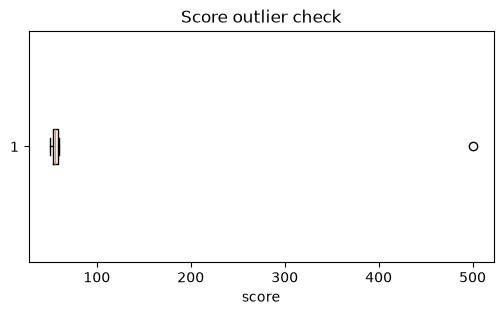

In [40]:
# boxplot: 중앙값, 사분위수, 이상값 후보를 한 번에 보여주는 그래프
plt.figure(figsize=(6, 3))
plt.boxplot(outlier_df["score"], orientation="horizontal")
plt.title("Score outlier check")
plt.xlabel("score")
plt.show()

### 03-5. 데이터 정규화: Z-score, Min-Max
- 정규화는 값의 범위를 맞추는 작업
    - 예를 들어 `income`은 천 단위이고, `purchase_count`는 한 자리 수라면 두 컬럼의 숫자 크기가 너무 다르다는 문제 발생.
    - 거리 기반 알고리즘이나 경사하강법 기반 모델에서는 값의 크기 차이가 학습에 영향을 줄 수 있습니다.
        - (참고) 경사하강법: 기반 모델은 예측 오차를 줄이는 방향으로 가중치를 조금씩 조정하면서 학습하는 모델.
        - 데이터 값의 크기 차이가 크면 학습이 불안정해질 수 있어, 보통 정규화나 표준화를 함께 사용함.

- Z-score 표준화: 평균을 0, 표준편차를 1에 가깝게 변환
- Min-Max 정규화: 값을 0부터 1 사이로 변환


In [44]:
# 단위와 숫자 크기가 서로 다른 score, income, purchase_count
scale_df = pd.DataFrame({
    "score": [45, 55, 60, 70, 95],
    "income": [2500, 3200, 4000, 5200, 9000],
    "purchase_count": [1, 2, 2, 4, 8],
})



In [45]:
# Z-score 표준화: 값이 평균에서 표준편차 몇 개만큼 떨어져 있는지 나타냄
# 공식: z = (값 - 평균) / 표준편차
score_mean = scale_df["score"].mean()

score_std = scale_df["score"].std(ddof=0) # 표준편차

scale_df["score_z"] = (scale_df["score"] - score_mean) / score_std
print('scale_df["score_z"]:', scale_df["score_z"])


scale_df["score_z"]: 0   -1.174440
1   -0.587220
2   -0.293610
3    0.293610
4    1.761661
Name: score_z, dtype: float64


In [47]:
# Min-Max 정규화: 최소값은 0, 최대값은 1이 되도록 변환.
# 공식: (값 - 최소값) / (최대값 - 최소값)
# 값의 범위를 0~1 사이로 맞추고 싶을 때 자주 사용gka
income_min = scale_df["income"].min()
income_max = scale_df["income"].max()
scale_df["income_minmax"] = (scale_df["income"] - income_min) / (income_max - income_min)
print('scale_df["income_minmax"]:\n', scale_df["income_minmax"])

scale_df["income_minmax"]:
 0    0.000000
1    0.107692
2    0.230769
3    0.415385
4    1.000000
Name: income_minmax, dtype: float64


### 03-6. 중심극한정리 맛보기
- “원래 데이터가 꼭 정규분포가 아니어도, 표본을 여러 번 뽑아 평균을 구하면 그 평균들의 분포는 정규분포에 가까워진다”는 내용


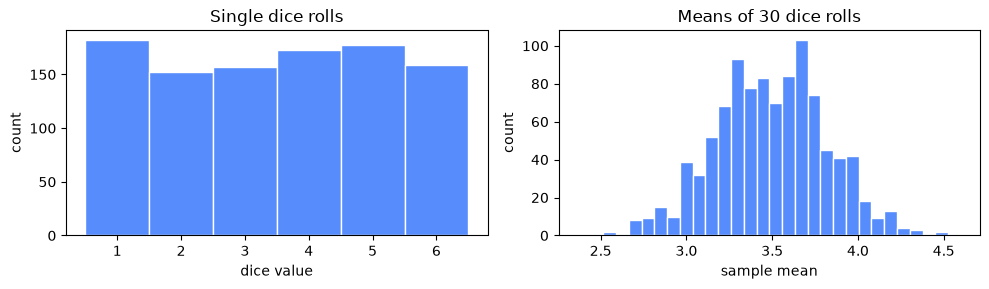

In [48]:
rng = np.random.default_rng(42)

# 주사위를 1000번 던진 결과
# 1~6 사이의 정수가 비슷한 빈도로 나오므로 원래 데이터는 균등분포에 가깝다.
single_rolls = rng.integers(1, 7, size=1000)

# 표본평균을 1000개 생성
# 한 번에 주사위를 30번 던져 평균을 구하고, 이 과정을 1000번 반복
# 중심극한정리의 핵심은 "개별 값"이 아니라 "표본평균들의 분포"를 보는 것!
sample_means = np.array([
    rng.integers(1, 7, size=30).mean()
    for _ in range(1000)
])

# 1행 2열 그래프를 만들어 왼쪽에는 개별 주사위 값, 오른쪽에는 표본평균 분포를 비교
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# bins를 0.5 단위로 밀어 주면 1, 2, 3, 4, 5, 6이 막대 중앙에 오도록 그릴 수 있음
axes[0].hist(single_rolls, bins=np.arange(1, 8) - 0.5, edgecolor="white")
axes[0].set_title("Single dice rolls")
axes[0].set_xlabel("dice value")
axes[0].set_ylabel("count")

# 표본평균은 1~6 전체에 고르게 퍼지지 않고, 평균값인 3.5 근처에 많이 모임
axes[1].hist(sample_means, bins=30, edgecolor="white")
axes[1].set_title("Means of 30 dice rolls")
axes[1].set_xlabel("sample mean")
axes[1].set_ylabel("count")

# 제목과 축 라벨이 겹치지 않도록 여백을 자동 조정
plt.tight_layout()
plt.show()

### 03-7. 다중대치 맛보기: `IterativeImputer`
- 결측값을 단순 평균으로 채우는 대신, 다른 변수들과의 관계를 이용해 결측값을 추정하는 방식
- 예를 들어 구매금액, 소득, 나이가 서로 어느 정도 관련이 있다면, 이 관계를 활용해 비어 있는 값을 더 그럴듯하게 채울 수 있음.
- 머신러닝의 `scikit-learn(사이킷런)`과 함께 더 자세히 다루면 좋음


In [53]:
!pip install scikit-learn

In [54]:
# 다중대치 예제에서는 수치형 컬럼만 사용
# IterativeImputer는 여러 컬럼의 관계를 이용해 결측값을 추정하므로 문자열 컬럼은 제외
impute_input_df = customer_work_df[["purchase1", "purchase2", "income", "age"]]
display(impute_input_df)

# IterativeImputer는 scikit-learn에서 아직 experimental 기능으로 제공된다.
# 그래서 enable_iterative_imputer를 먼저 import해야 사용할 수 있음
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

# random_state는 재현 가능한 결과를 위해 고정
# max_iter는 결측값 추정을 반복할 최대 횟수
imputer = IterativeImputer(random_state=42, max_iter=10)

# fit_transform(): 데이터의 패턴을 학습하고 결측치를 채운 배열을 반환
# 반환값은 NumPy 배열이므로 다시 DataFrame으로 바꾸면 비교하기 좋음
imputed_array = imputer.fit_transform(impute_input_df)

imputed_df = pd.DataFrame(
    imputed_array,
    columns=["purchase1_fill", "purchase2_fill", "income_fill", "age_fill"],
).round(1)

display(imputed_df)

,purchase1,purchase2,income,age
0,120000.0,90000.0,3200.0,25.0
1,350000.0,120000.0,5400.0,38.0
2,80000.0,40000.0,NaN,NaN
3,500000.0,620000.0,9100.0,45.0
4,NaN,30000.0,2800.0,29.0
5,150000.0,NaN,4500.0,33.0
6,70000.0,65000.0,3000.0,NaN


,purchase1_fill,purchase2_fill,income_fill,age_fill
0,120000.0,90000.0,3200.0,25.0
1,350000.0,120000.0,5400.0,38.0
2,80000.0,40000.0,2962.7,26.7
3,500000.0,620000.0,9100.0,45.0
4,120890.6,30000.0,2800.0,29.0
5,150000.0,101464.7,4500.0,33.0
6,70000.0,65000.0,3000.0,26.2
